In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

In [2]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

In [3]:
DATA_PATH = Path("../data/raw/bank.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
target_col = "deposit"

y = df[target_col].map({
    "no": 0,
    "yes": 1,
})

print("y shape:", y.shape)

target_distribution = pd.DataFrame({
    "count": y.value_counts().sort_index(),
    "proportion": y.value_counts(normalize=True).sort_index(),
})

target_distribution

y shape: (11162,)


,count,proportion
deposit,,
0,5873,0.5262
1,5289,0.4738


In [5]:
excluded_cols = [
    "deposit",
    "duration",
]

X = df.drop(columns=excluded_cols)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nExcluded columns:")
print(excluded_cols)

print("\nIs deposit in X?", "deposit" in X.columns)
print("Is duration in X?", "duration" in X.columns)

X shape: (11162, 15)
y shape: (11162,)

Excluded columns:
['deposit', 'duration']

Is deposit in X? False
Is duration in X? False


In [6]:
numeric_features = [
    "age",
    "balance",
    "day",
    "campaign",
    "pdays",
    "previous",
]

categorical_features = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome",
]

expected_features = numeric_features + categorical_features

print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))
print("Total expected features:", len(expected_features))
print("Actual X features:", X.shape[1])

print("\nMissing from X:")
print(set(expected_features) - set(X.columns))

print("\nUnexpected in X:")

Number of numeric features: 6
Number of categorical features: 9
Total expected features: 15
Actual X features: 15

Missing from X:
set()

Unexpected in X:


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8929, 15)
X_test: (2233, 15)
y_train: (8929,)
y_test: (2233,)


In [8]:
def target_distribution_by_split(series, split_name):
    counts = series.value_counts().sort_index()
    proportions = series.value_counts(normalize=True).sort_index()
    
    return pd.DataFrame({
        "split": split_name,
        "class": counts.index,
        "count": counts.values,
        "proportion": proportions.values,
    })

In [9]:
target_distribution_table = pd.concat(
    [
        target_distribution_by_split(y, "full"),
        target_distribution_by_split(y_train, "train"),
        target_distribution_by_split(y_test, "test"),
    ],
    ignore_index=True,
)

target_distribution_table

,split,class,count,proportion
0,full,0,5873,0.5262
1,full,1,5289,0.4738
2,train,0,4698,0.5262
3,train,1,4231,0.4738
4,test,0,1175,0.5262
5,test,1,1058,0.4738


## Stage 5 — Controlled candidate refinement and threshold analysis setup

Task type: binary classification.

Target: `deposit`.

Positive class: `yes`, encoded as `1`.

Main scenario: pre-contact prediction.

Controlled setup reused from previous stages:

- `y = deposit`, with `no -> 0`, `yes -> 1`
- `X = df.drop(columns=["deposit", "duration"])`
- `duration` excluded because it is leakage-risk
- `unknown` values kept as categorical levels
- same stratified train/test split:
  - `test_size=0.2`
  - `random_state=42`
  - `stratify=y`

Important:

`X_test` is created only to preserve the final holdout split. It must not be used for threshold analysis or model comparison in Stage 5.

Threshold analysis will be based only on out-of-fold predicted probabilities from `X_train`.

In [10]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [11]:
numeric_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessor, numeric_features),
        ("cat", categorical_preprocessor, categorical_features),
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [12]:
candidate_models = {
    "HistGradientBoostingClassifier": HistGradientBoostingClassifier(
        random_state=42,
    ),
    "RandomForestClassifier": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
    ),
    "GradientBoostingClassifier": GradientBoostingClassifier(
        random_state=42,
    ),
    "LogisticRegression balanced": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
    ),
}

candidate_models

{'HistGradientBoostingClassifier': HistGradientBoostingClassifier(random_state=42),
 'RandomForestClassifier': RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
 'GradientBoostingClassifier': GradientBoostingClassifier(random_state=42),
 'LogisticRegression balanced': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)}

In [13]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

In [14]:
def classification_metrics_at_threshold(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }

Ячейка — OOF predicted probabilities

In [15]:
oof_predictions = {}
default_threshold_results = []
ranking_results = []

for model_name, model in candidate_models.items():
    clf = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )
    
    y_train_oof_proba = cross_val_predict(
        clf,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]
    
    oof_predictions[model_name] = y_train_oof_proba
    
    default_metrics = classification_metrics_at_threshold(
        y_true=y_train,
        y_proba=y_train_oof_proba,
        threshold=0.5,
    )
    default_metrics["model"] = model_name
    default_threshold_results.append(default_metrics)
    
    ranking_results.append({
        "model": model_name,
        "roc_auc": roc_auc_score(y_train, y_train_oof_proba),
        "pr_auc": average_precision_score(y_train, y_train_oof_proba),
    })

default_threshold_results_df = (
    pd.DataFrame(default_threshold_results)
    .loc[
        :,
        [
            "model",
            "threshold",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "tn",
            "fp",
            "fn",
            "tp",
        ],
    ]
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)

ranking_results_df = (
    pd.DataFrame(ranking_results)
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

default_threshold_results_df

,model,threshold,accuracy,precision,recall,f1,tn,fp,fn,tp
0,HistGradientBoostingClassifier,0.5000,0.7349,0.7689,0.6299,0.6925,3897,801,1566,2665
1,RandomForestClassifier,0.5000,0.7257,0.7398,0.6497,0.6918,3731,967,1482,2749
2,GradientBoostingClassifier,0.5000,0.7342,0.7798,0.6119,0.6857,3967,731,1642,2589
3,LogisticRegression balanced,0.5000,0.7018,0.7118,0.6228,0.6643,3631,1067,1596,2635


Ячейка — rounded default threshold results

In [16]:
default_threshold_results_rounded = default_threshold_results_df.copy()

metric_cols = [
    "threshold",
    "accuracy",
    "precision",
    "recall",
    "f1",
]

default_threshold_results_rounded[metric_cols] = (
    default_threshold_results_rounded[metric_cols].round(4)
)

default_threshold_results_rounded

,model,threshold,accuracy,precision,recall,f1,tn,fp,fn,tp
0,HistGradientBoostingClassifier,0.5000,0.7349,0.7689,0.6299,0.6925,3897,801,1566,2665
1,RandomForestClassifier,0.5000,0.7257,0.7398,0.6497,0.6918,3731,967,1482,2749
2,GradientBoostingClassifier,0.5000,0.7342,0.7798,0.6119,0.6857,3967,731,1642,2589
3,LogisticRegression balanced,0.5000,0.7018,0.7118,0.6228,0.6643,3631,1067,1596,2635


Ячейка — ranking metrics

In [17]:
ranking_results_rounded = ranking_results_df.copy()

ranking_results_rounded[["roc_auc", "pr_auc"]] = (
    ranking_results_rounded[["roc_auc", "pr_auc"]].round(4)
)

ranking_results_rounded

,model,roc_auc,pr_auc
0,HistGradientBoostingClassifier,0.7893,0.7827
1,GradientBoostingClassifier,0.7860,0.7825
2,RandomForestClassifier,0.7801,0.7723
3,LogisticRegression balanced,0.7630,0.7628


Ячейка — thresholds grid

In [18]:
thresholds = np.round(np.arange(0.10, 0.91, 0.05), 2)

thresholds

array([0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55, 0.6 ,
       0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 ])

Ячейка — threshold metrics for all models

In [19]:
threshold_results = []

for model_name, y_train_oof_proba in oof_predictions.items():
    for threshold in thresholds:
        metrics = classification_metrics_at_threshold(
            y_true=y_train,
            y_proba=y_train_oof_proba,
            threshold=threshold,
        )
        metrics["model"] = model_name
        threshold_results.append(metrics)

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df = threshold_results_df[
    [
        "model",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "tn",
        "fp",
        "fn",
        "tp",
    ]
]

threshold_results_rounded = threshold_results_df.copy()

threshold_results_rounded[
    ["threshold", "accuracy", "precision", "recall", "f1"]
] = threshold_results_rounded[
    ["threshold", "accuracy", "precision", "recall", "f1"]
].round(4)

threshold_results_rounded.head()

,model,threshold,accuracy,precision,recall,f1,tn,fp,fn,tp
0,HistGradientBoostingClassifier,0.1000,0.4911,0.4820,0.9931,0.6491,183,4515,29,4202
1,HistGradientBoostingClassifier,0.1500,0.5300,0.5021,0.9721,0.6622,619,4079,118,4113
2,HistGradientBoostingClassifier,0.2000,0.5801,0.5324,0.9362,0.6788,1219,3479,270,3961
3,HistGradientBoostingClassifier,0.2500,0.6252,0.5671,0.8830,0.6906,1846,2852,495,3736
4,HistGradientBoostingClassifier,0.3000,0.6667,0.6082,0.8336,0.7033,2426,2272,704,3527


Ячейка — best threshold by F1 for each model

In [20]:
best_threshold_by_model = (
    threshold_results_rounded
    .sort_values(["model", "f1"], ascending=[True, False])
    .groupby("model", as_index=False)
    .head(1)
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)

best_threshold_by_model

,model,threshold,accuracy,precision,recall,f1,tn,fp,fn,tp
0,HistGradientBoostingClassifier,0.3500,0.6972,0.6515,0.7762,0.7084,2941,1757,947,3284
1,RandomForestClassifier,0.4000,0.7052,0.6674,0.7532,0.7078,3110,1588,1044,3187
2,GradientBoostingClassifier,0.4000,0.7102,0.6787,0.7374,0.7068,3221,1477,1111,3120
3,LogisticRegression balanced,0.4000,0.6598,0.6073,0.7979,0.6897,2515,2183,855,3376


Ячейка — global best threshold by F1

In [21]:
best_threshold_overall = (
    threshold_results_rounded
    .sort_values("f1", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

best_threshold_overall

,model,threshold,accuracy,precision,recall,f1,tn,fp,fn,tp
0,HistGradientBoostingClassifier,0.3500,0.6972,0.6515,0.7762,0.7084,2941,1757,947,3284
1,HistGradientBoostingClassifier,0.4000,0.7174,0.6938,0.7225,0.7079,3349,1349,1174,3057
2,RandomForestClassifier,0.4000,0.7052,0.6674,0.7532,0.7078,3110,1588,1044,3187
3,GradientBoostingClassifier,0.4000,0.7102,0.6787,0.7374,0.7068,3221,1477,1111,3120
4,RandomForestClassifier,0.4500,0.7207,0.7036,0.7093,0.7065,3434,1264,1230,3001
5,RandomForestClassifier,0.3500,0.6794,0.6258,0.8041,0.7038,2664,2034,829,3402
6,HistGradientBoostingClassifier,0.3000,0.6667,0.6082,0.8336,0.7033,2426,2272,704,3527
7,GradientBoostingClassifier,0.3500,0.6745,0.6193,0.8126,0.7029,2585,2113,793,3438
8,HistGradientBoostingClassifier,0.4500,0.7295,0.7338,0.6736,0.7024,3664,1034,1381,2850
9,GradientBoostingClassifier,0.4500,0.7255,0.7286,0.6705,0.6983,3641,1057,1394,2837


Ячейка — focused threshold table for recommended models

In [22]:
focused_thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

focused_threshold_table = threshold_results_rounded[
    threshold_results_rounded["threshold"].isin(focused_thresholds)
].sort_values(["model", "threshold"])

focused_threshold_table

,model,threshold,accuracy,precision,recall,f1,tn,fp,fn,tp
38,GradientBoostingClassifier,0.3000,0.6281,0.5699,0.8769,0.6908,1898,2800,521,3710
39,GradientBoostingClassifier,0.3500,0.6745,0.6193,0.8126,0.7029,2585,2113,793,3438
40,GradientBoostingClassifier,0.4000,0.7102,0.6787,0.7374,0.7068,3221,1477,1111,3120
41,GradientBoostingClassifier,0.4500,0.7255,0.7286,0.6705,0.6983,3641,1057,1394,2837
42,GradientBoostingClassifier,0.5000,0.7342,0.7798,0.6119,0.6857,3967,731,1642,2589
43,GradientBoostingClassifier,0.5500,0.7315,0.8166,0.5590,0.6637,4167,531,1866,2365
44,GradientBoostingClassifier,0.6000,0.7205,0.8382,0.5082,0.6327,4283,415,2081,2150
45,GradientBoostingClassifier,0.6500,0.7047,0.8520,0.4559,0.5940,4363,335,2302,1929
46,GradientBoostingClassifier,0.7000,0.6879,0.8672,0.4030,0.5503,4437,261,2526,1705
4,HistGradientBoostingClassifier,0.3000,0.6667,0.6082,0.8336,0.7033,2426,2272,704,3527


Ячейка — precision/recall trade-off for HistGradientBoostingClassifier

In [23]:
hgb_threshold_table = (
    threshold_results_rounded[
        threshold_results_rounded["model"] == "HistGradientBoostingClassifier"
    ]
    .sort_values("threshold")
    .reset_index(drop=True)
)

hgb_threshold_table

,model,threshold,accuracy,precision,recall,f1,tn,fp,fn,tp
0,HistGradientBoostingClassifier,0.1000,0.4911,0.4820,0.9931,0.6491,183,4515,29,4202
1,HistGradientBoostingClassifier,0.1500,0.5300,0.5021,0.9721,0.6622,619,4079,118,4113
2,HistGradientBoostingClassifier,0.2000,0.5801,0.5324,0.9362,0.6788,1219,3479,270,3961
3,HistGradientBoostingClassifier,0.2500,0.6252,0.5671,0.8830,0.6906,1846,2852,495,3736
4,HistGradientBoostingClassifier,0.3000,0.6667,0.6082,0.8336,0.7033,2426,2272,704,3527
5,HistGradientBoostingClassifier,0.3500,0.6972,0.6515,0.7762,0.7084,2941,1757,947,3284
6,HistGradientBoostingClassifier,0.4000,0.7174,0.6938,0.7225,0.7079,3349,1349,1174,3057
7,HistGradientBoostingClassifier,0.4500,0.7295,0.7338,0.6736,0.7024,3664,1034,1381,2850
8,HistGradientBoostingClassifier,0.5000,0.7349,0.7689,0.6299,0.6925,3897,801,1566,2665
9,HistGradientBoostingClassifier,0.5500,0.7363,0.7995,0.5918,0.6802,4070,628,1727,2504


Ячейка — precision/recall trade-off for RandomForestClassifier

In [24]:
rf_threshold_table = (
    threshold_results_rounded[
        threshold_results_rounded["model"] == "RandomForestClassifier"
    ]
    .sort_values("threshold")
    .reset_index(drop=True)
)

rf_threshold_table

,model,threshold,accuracy,precision,recall,f1,tn,fp,fn,tp
0,RandomForestClassifier,0.1000,0.4986,0.4857,0.9868,0.6510,277,4421,56,4175
1,RandomForestClassifier,0.1500,0.5277,0.5009,0.9664,0.6598,623,4075,142,4089
2,RandomForestClassifier,0.2000,0.5633,0.5218,0.9395,0.6709,1055,3643,256,3975
3,RandomForestClassifier,0.2500,0.6059,0.5516,0.8996,0.6839,1604,3094,425,3806
4,RandomForestClassifier,0.3000,0.6422,0.5842,0.8497,0.6923,2139,2559,636,3595
5,RandomForestClassifier,0.3500,0.6794,0.6258,0.8041,0.7038,2664,2034,829,3402
6,RandomForestClassifier,0.4000,0.7052,0.6674,0.7532,0.7078,3110,1588,1044,3187
7,RandomForestClassifier,0.4500,0.7207,0.7036,0.7093,0.7065,3434,1264,1230,3001
8,RandomForestClassifier,0.5000,0.7257,0.7398,0.6497,0.6918,3731,967,1482,2749
9,RandomForestClassifier,0.5500,0.7279,0.7741,0.6010,0.6767,3956,742,1688,2543


Ячейка — threshold curves

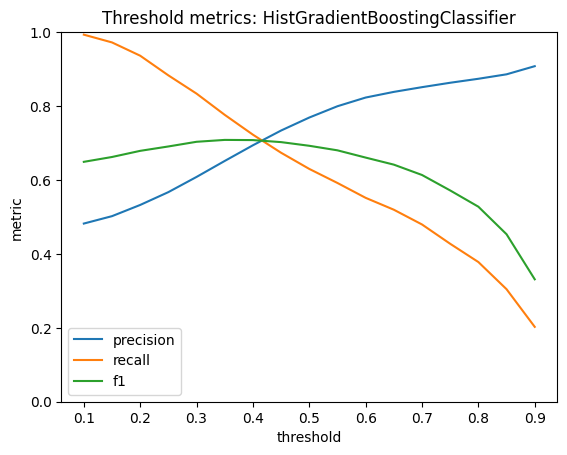

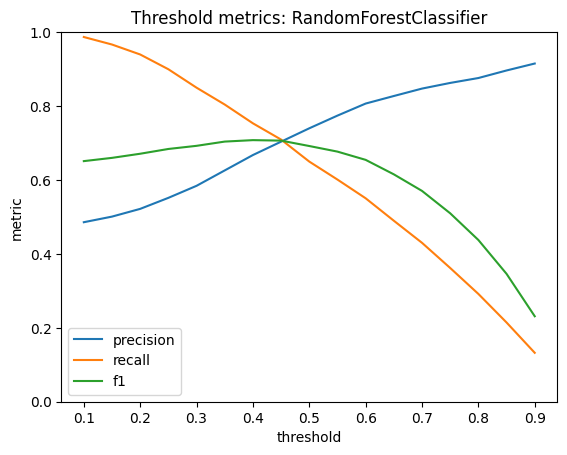

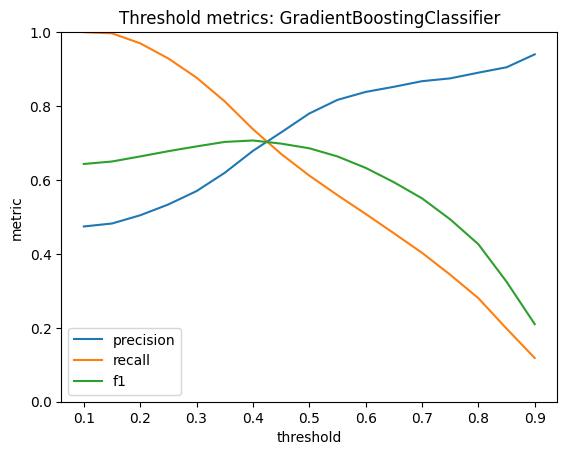

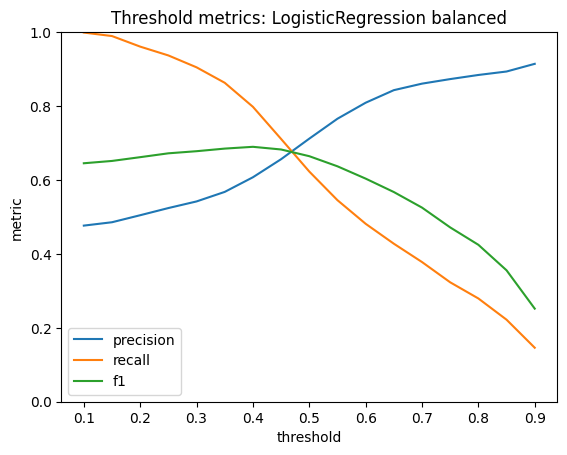

In [26]:
from matplotlib import pyplot as plt

for model_name in candidate_models.keys():
    model_thresholds = threshold_results_df[
        threshold_results_df["model"] == model_name
    ].sort_values("threshold")
    
    plt.plot(model_thresholds["threshold"], model_thresholds["precision"], label="precision")
    plt.plot(model_thresholds["threshold"], model_thresholds["recall"], label="recall")
    plt.plot(model_thresholds["threshold"], model_thresholds["f1"], label="f1")
    
    plt.title(f"Threshold metrics: {model_name}")
    plt.xlabel("threshold")
    plt.ylabel("metric")
    plt.ylim(0, 1)
    plt.legend()
    plt.show()

## Threshold analysis logic

Threshold analysis is performed only using out-of-fold predicted probabilities from `X_train`.

No threshold is selected using `X_test`.

For each candidate model, thresholds from 0.10 to 0.90 were evaluated.

Metrics by threshold:

- precision
- recall
- F1
- true negatives
- false positives
- false negatives
- true positives

Interpretation:

- Lower threshold usually increases recall but lowers precision.
- Higher threshold usually increases precision but lowers recall.
- F1 is a balanced summary of precision and recall, but it is not automatically the final business objective.

## Stage 5 — Controlled candidate refinement and threshold analysis conclusions

### Setup

Task type: binary classification.

Target: `deposit`.

Positive class: `yes`, encoded as `1`.

Main scenario: pre-contact prediction.

Controlled setup reused from previous stages:

- `y = deposit`, with `no -> 0`, `yes -> 1`
- `X = df.drop(columns=["deposit", "duration"])`
- `duration` excluded due to leakage risk
- `unknown` values kept as categorical levels
- same stratified train/test split:
  - `test_size=0.2`
  - `random_state=42`
  - `stratify=y`

`X_test` was created but not used for model comparison, threshold analysis, or final evaluation.

### Candidate models

Models compared:

- `HistGradientBoostingClassifier`
- `RandomForestClassifier`
- `GradientBoostingClassifier`
- `LogisticRegression(class_weight="balanced")`

All preprocessing was kept inside `Pipeline` / `ColumnTransformer`.

### OOF logic

Stage 5 uses 5-fold `StratifiedKFold` out-of-fold predicted probabilities on `X_train`.

This means each training row receives a predicted probability from a model that was not trained on that row.

Threshold analysis is performed only on these train-only OOF probabilities.

No threshold was selected using `X_test`.

### Default threshold results

At threshold `0.5`:

| model | threshold | accuracy | precision | recall | F1 | TN | FP | FN | TP |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| HistGradientBoostingClassifier | 0.50 | 0.7349 | 0.7689 | 0.6299 | 0.6925 | 3897 | 801 | 1566 | 2665 |
| RandomForestClassifier | 0.50 | 0.7257 | 0.7398 | 0.6497 | 0.6918 | 3731 | 967 | 1482 | 2749 |
| GradientBoostingClassifier | 0.50 | 0.7342 | 0.7798 | 0.6119 | 0.6857 | 3967 | 731 | 1642 | 2589 |
| LogisticRegression balanced | 0.50 | 0.7018 | 0.7118 | 0.6228 | 0.6643 | 3631 | 1067 | 1596 | 2635 |

Best default-threshold candidate:

- `HistGradientBoostingClassifier`
- F1 = 0.6925
- precision = 0.7689
- recall = 0.6299

`RandomForestClassifier` is very close by F1 and has higher recall at the default threshold.

### Ranking metrics

| model | ROC-AUC | PR-AUC |
|---|---:|---:|
| HistGradientBoostingClassifier | 0.7893 | 0.7827 |
| GradientBoostingClassifier | 0.7860 | 0.7825 |
| RandomForestClassifier | 0.7801 | 0.7723 |
| LogisticRegression balanced | 0.7630 | 0.7628 |

Best ranking candidate:

- `HistGradientBoostingClassifier`

However, `GradientBoostingClassifier` is almost tied by PR-AUC.

### Best threshold by OOF F1

Best threshold by F1 for each model:

| model | threshold | accuracy | precision | recall | F1 | TN | FP | FN | TP |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| HistGradientBoostingClassifier | 0.35 | 0.6972 | 0.6515 | 0.7762 | 0.7084 | 2941 | 1757 | 947 | 3284 |
| RandomForestClassifier | 0.40 | 0.7052 | 0.6674 | 0.7532 | 0.7078 | 3110 | 1588 | 1044 | 3187 |
| GradientBoostingClassifier | 0.40 | 0.7102 | 0.6787 | 0.7374 | 0.7068 | 3221 | 1477 | 1111 | 3120 |
| LogisticRegression balanced | 0.40 | 0.6598 | 0.6073 | 0.7979 | 0.6897 | 2515 | 2183 | 855 | 3376 |

Overall best OOF-F1 threshold policy:

- `HistGradientBoostingClassifier`
- threshold = `0.35`
- F1 = `0.7084`
- precision = `0.6515`
- recall = `0.7762`

### Precision / recall trade-off

For `HistGradientBoostingClassifier`:

At threshold `0.50`:

- precision = 0.7689
- recall = 0.6299
- F1 = 0.6925
- FP = 801
- FN = 1566

At threshold `0.35`:

- precision = 0.6515
- recall = 0.7762
- F1 = 0.7084
- FP = 1757
- FN = 947

Lowering the threshold from 0.50 to 0.35:

- increases recall from 0.6299 to 0.7762
- decreases precision from 0.7689 to 0.6515
- reduces false negatives from 1566 to 947
- increases false positives from 801 to 1757

Interpretation:

- If the business cost of missing potential deposit subscribers is high, the lower threshold may be attractive.
- If sales capacity is limited or false positives are expensive, threshold 0.50 or a more conservative threshold may be preferable.

### Candidate for later final evaluation

Recommended candidate to reserve for later final evaluation:

- `HistGradientBoostingClassifier` with threshold policy around `0.35`, if the business goal prioritizes F1 / recall balance.
- `RandomForestClassifier` with threshold around `0.40` is a close alternative with slightly higher precision and slightly lower recall.
- `HistGradientBoostingClassifier` at default threshold `0.50` remains a more conservative policy with higher precision.

Important:

This is not final model selection yet.

The threshold policy was selected only using train-only OOF predictions. It must not be treated as final until the final holdout evaluation stage.

### Leakage checks

Passed:

- `duration` excluded from `X`
- `duration` excluded from `X_train`
- `duration` excluded from `X_test`
- `deposit` excluded from `X`
- `deposit` excluded from `X_train`
- `deposit` excluded from `X_test`
- `unknown` values kept as categorical levels
- preprocessing placed inside `Pipeline` / `ColumnTransformer`
- OOF predicted probabilities generated only on `X_train`
- threshold analysis performed only on train-only OOF predictions
- `X_test` not evaluated
- no huge GridSearchCV
- no threshold selected using final holdout test